# Step 1. Market Segmentation via Unsupervised Clustering

The first stage of the analysis aims to identify structural differences across U.S. EV markets. Instead of pre-defining market categories, we apply **unsupervised clustering** to group states with similar EV adoption, demographic characteristics, and charging infrastructure conditions.

The purpose of this step is to discover **natural market segments** in the EV ecosystem. These clusters will later be interpreted in economic terms in Step 2.

---

# 1.1 Objective

The goal of Step 1 is to divide U.S. states into groups that share similar EV market characteristics. States within the same cluster should exhibit comparable patterns in:

- EV adoption levels  
- population structure  
- income levels  
- urbanisation  
- charging infrastructure availability  

Unlike supervised learning, clustering does not rely on predefined labels. Instead, it identifies patterns in the data based on similarity across multiple variables.

The clustering results provide a **data-driven market segmentation**, which forms the foundation for later economic interpretation and strategic analysis.

---

# 1.2 Input Data

The dataset contains state-level indicators describing EV adoption, demographic characteristics, and charging infrastructure.

Key variables include:

- `Registration Count`
- `Mean households income`
- `Population`
- `Population Density`
- `Mean travel time to work`
- `URBAN POP`
- `URBAN POP_PCT`
- `EV Charging Station`
- `EV Charging Port`

These variables capture both **demand-side factors** and **infrastructure supply conditions**.

---

# 1.3 Feature Engineering

Because states vary greatly in population size, raw totals are not directly comparable. To address this issue, several **normalized indicators** are constructed.

### EV adoption intensity

$$
registrations\_per\_1k\_pop =
\frac{Registration\ Count}{Population} \times 1000
$$

This variable measures the intensity of EV adoption relative to population size.

---

### Charging infrastructure density

Stations per population:

$$
stations\_per\_100k =
\frac{EV\ Charging\ Station}{Population} \times 100000
$$

Ports per population:

$$
ports\_per\_100k =
\frac{EV\ Charging\ Port}{Population} \times 100000
$$

These variables measure the availability of charging infrastructure relative to the size of the state.

---

### Infrastructure capacity

$$
ports\_per\_station =
\frac{EV\ Charging\ Port}{EV\ Charging\ Station}
$$

This indicates the average capacity of charging locations.

---

### Urbanisation indicator

Urbanisation plays a key role in EV adoption due to higher travel demand density and shorter commuting distances. Therefore, the percentage of urban population (`URBAN POP_PCT`) is included as a structural variable.

---

# 1.4 Feature Selection

After feature engineering, the clustering algorithm uses a set of variables representing EV demand, socio-economic characteristics, and infrastructure conditions.

The selected features include:

- `registrations_per_1k_pop`
- `Mean households income`
- `Population Density`
- `Mean travel time to work`
- `URBAN POP_PCT`
- `stations_per_100k`
- `ports_per_100k`
- `ports_per_station`

These variables collectively describe the **market environment of EV adoption**.

## 1.4.1 Feature Selection Validation

Although the selected features are motivated by domain knowledge, it is also important to verify that they are empirically reasonable for clustering.

Three validation steps are used.

### Correlation analysis
A correlation heatmap is used to examine whether some variables contain highly overlapping information. This helps detect potential redundancy, especially among variables describing similar dimensions such as urbanisation or charging infrastructure.

### PCA loadings
A PCA loadings table is used to assess whether the selected variables meaningfully contribute to the principal components. This provides evidence that the chosen features are not only theoretically relevant, but also empirically important in shaping the structure of the dataset.

### Feature sensitivity / ablation test
A feature sensitivity test is conducted by removing selected variables and re-running the clustering procedure. If the resulting cluster quality remains stable, this suggests that the segmentation is robust. If the clustering outcome changes substantially, this indicates that the removed feature plays an important role in shaping market typology.

Together, these checks provide additional support for the chosen feature set and reduce the risk that the clustering results are driven by arbitrary variable selection.

---

# 1.5 Feature Scaling

The selected variables have different units and scales. For example:

- income is measured in dollars
- population density is measured per square kilometre
- charging stations are counts

To ensure that no single variable dominates the clustering process, all features are standardized using **z-score normalization**:

$$
z =
\frac{x - \mu}{\sigma}
$$

where

- \(x\) is the original value  
- \(\mu\) is the mean of the feature  
- \(\sigma\) is the standard deviation  

Standardization ensures that each feature contributes equally to the clustering algorithm.

---

# 1.6 Clustering Algorithm

The clustering step uses the **K-Means algorithm**, which partitions observations into \(K\) clusters by minimizing within-cluster variance.

The objective function of K-Means is:

$$
\min \sum_{k=1}^{K} \sum_{i \in C_k}
\|x_i - \mu_k\|^2
$$

where:

- \(x_i\) represents a data point
- \(\mu_k\) is the centroid of cluster \(k\)
- \(C_k\) represents the set of points assigned to cluster \(k\)

The algorithm iteratively performs two steps:

1. **Assignment step**

Each observation is assigned to the nearest cluster centroid.

2. **Update step**

Cluster centroids are recalculated as the mean of observations within each cluster.

This process continues until the cluster assignments stabilize.

---

# 1.7 Determining the Number of Clusters

The number of clusters \(K\) is determined using the **elbow method**.

The elbow method evaluates the **within-cluster sum of squares (WCSS)** as the number of clusters increases.

As \(K\) increases, WCSS decreases. However, after a certain point, the marginal improvement becomes small. The optimal number of clusters is typically chosen at the **elbow point**, where additional clusters no longer significantly reduce WCSS.

---

# 1.8 Cluster Assignment

Once the optimal value of \(K\) is selected, each state is assigned to one of the clusters.

The clustering output dataset contains:

- `State`
- `cluster`
- engineered features
- PCA coordinates for visualization

This allows the analysis to track which states belong to each market segment.

---

# 1.9 PCA Visualization

To visualize the clustering results, **Principal Component Analysis (PCA)** is applied to reduce the feature space to two dimensions.

PCA constructs new orthogonal variables (principal components) that capture the maximum variance in the data.

The first two components are defined as:

$$
PC_1 = w_1^T X
$$

$$
PC_2 = w_2^T X
$$

where \(w_1\) and \(w_2\) are eigenvectors of the covariance matrix.

Plotting states on the \(PC_1\)–\(PC_2\) plane provides an intuitive visual representation of cluster separation.

States that are close together in the PCA plot share similar EV market characteristics.

---

# 1.10 Interpretation of Clusters

The clustering results reveal structural heterogeneity across U.S. EV markets. Instead of assuming that all states follow the same development path, the analysis identifies groups of states with similar adoption patterns and infrastructure conditions.

These clusters represent different **market archetypes**, which may correspond to:

- mature EV markets with strong infrastructure  
- emerging markets with growing EV adoption  
- infrastructure-constrained markets  
- low-adoption markets  

However, clustering alone does not explain the economic meaning of these groups. Therefore, the next step is to interpret the clusters in terms of **demand, supply, competition, and growth potential**.

This interpretation is conducted in **Step 2**.

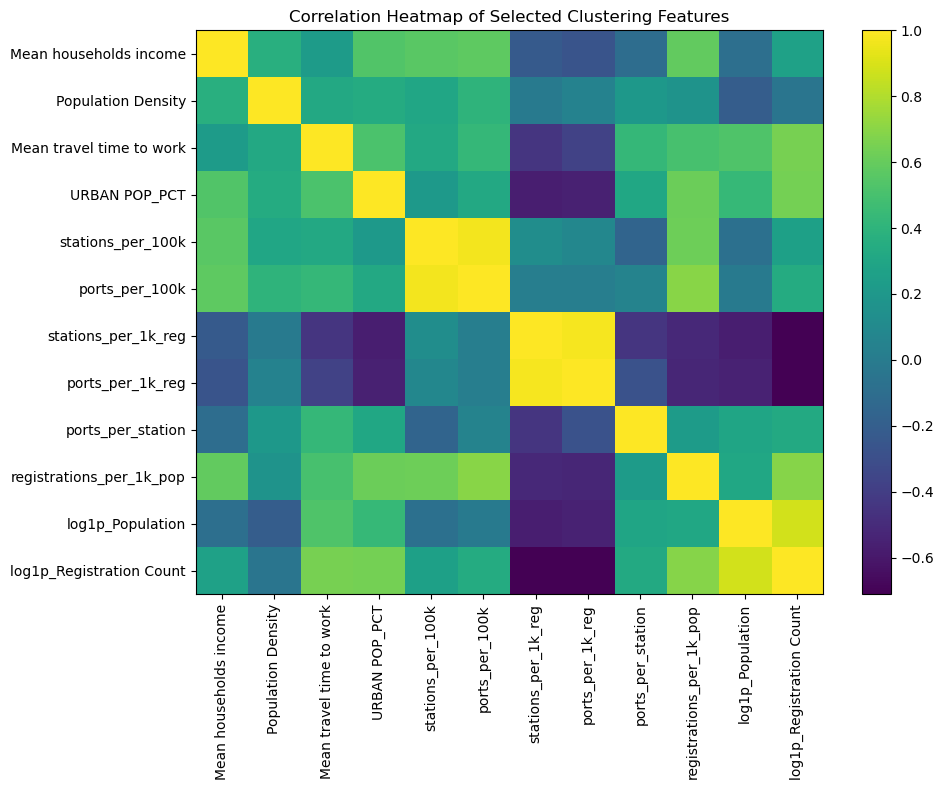

Correlation matrix:
                          Mean households income  Population Density  \
Mean households income                     1.000               0.371   
Population Density                         0.371               1.000   
Mean travel time to work                   0.230               0.324   
URBAN POP_PCT                              0.535               0.339   
stations_per_100k                          0.561               0.300   
ports_per_100k                             0.575               0.402   
stations_per_1k_reg                       -0.224              -0.013   
ports_per_1k_reg                          -0.268               0.050   
ports_per_station                         -0.099               0.201   
registrations_per_1k_pop                   0.586               0.165   
log1p_Population                          -0.088              -0.203   
log1p_Registration Count                   0.266              -0.045   

                          Mean travel time 

c:\Users\ASUS\anaconda3\envs\water-supply\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ASUS\anaconda3\envs\water-supply\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ASUS\anaconda3\envs\water-supply\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ASUS\anaconda3\envs\water-supply\Lib\site-packages\sklearn\cluster\_kmeans.p


Ablation test (selected feature drops):
                     feature_set  n_features  silhouette  inertia
                Full feature set          12      0.2751 244.9212
Without Mean travel time to work          11      0.2878 216.7161
       Without ports_per_station          11      0.2898 205.8266
      Without Population Density          11      0.2636 221.3630


c:\Users\ASUS\anaconda3\envs\water-supply\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ASUS\anaconda3\envs\water-supply\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ASUS\anaconda3\envs\water-supply\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ASUS\anaconda3\envs\water-supply\Lib\site-packages\sklearn\cluster\_kmeans.p


Single-feature drop sensitivity table:
         dropped_feature  n_features  silhouette  inertia
  Mean households income          11      0.2923 215.3605
       ports_per_station          11      0.2898 205.8266
Mean travel time to work          11      0.2878 216.7161
      Population Density          11      0.2636 221.3630
        log1p_Population          11      0.2539 214.8632
log1p_Registration Count          11      0.2458 226.7052
           URBAN POP_PCT          11      0.2407 227.5998
        ports_per_1k_reg          11      0.2402 226.8153
          ports_per_100k          11      0.2378 222.7519
registrations_per_1k_pop          11      0.2241 227.3214
     stations_per_1k_reg          11      0.2163 230.2728
       stations_per_100k          11      0.1912 219.8962

Cluster profile (KMeans, mean of engineered features):
         Mean households income  Population Density  Mean travel time to work  URBAN POP_PCT  stations_per_100k  ports_per_100k  stations_per_1k_reg  

c:\Users\ASUS\anaconda3\envs\water-supply\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ASUS\anaconda3\envs\water-supply\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [6]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


def load_state_data(csv_path: str) -> pd.DataFrame:
    """Read the state-level dataset and keep a clean, analysis-ready schema.

    Focus on reproducibility: load once, standardise column handling, and
    preserve the state identifier for later labelling and reporting.
    """
    df = pd.read_csv(csv_path)

    # Keep 'State' as an identifier rather than a numeric feature.
    if "State" not in df.columns:
        raise ValueError("Expected a 'State' column but did not find one.")

    return df


def winsorise_series(s: pd.Series, lower_q: float = 0.01, upper_q: float = 0.99) -> pd.Series:
    """Clip extreme values to reduce the influence of outliers on distance-based clustering.

    Winsorisation is a pragmatic choice here because we want stable clusters
    while still keeping all states in the analysis.
    """
    lo = s.quantile(lower_q)
    hi = s.quantile(upper_q)
    return s.clip(lower=lo, upper=hi)


def engineer_features(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    """Create market-structure features that reflect demand, infrastructure, and intensity.

    Prefer per-capita and per-vehicle ratios to avoid clustering by state size.
    Apply log transforms to heavily skewed absolute counts to stabilise distances.
    """
    required = [
        "Registration Count",
        "Mean households income",
        "Population",
        "Population Density",
        "Mean travel time to work",
        "URBAN POP",
        "URBAN POP_PCT",
        "EV Charging Station",
        "EV Charging Port",
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    out = df.copy()

    # ---------- Ratios (the core “high-score” engineering) ----------
    out["stations_per_100k"] = out["EV Charging Station"] / out["Population"] * 100_000
    out["ports_per_100k"] = out["EV Charging Port"] / out["Population"] * 100_000

    out["stations_per_1k_reg"] = out["EV Charging Station"] / out["Registration Count"] * 1_000
    out["ports_per_1k_reg"] = out["EV Charging Port"] / out["Registration Count"] * 1_000

    out["ports_per_station"] = out["EV Charging Port"] / out["EV Charging Station"].replace(0, np.nan)
    out["registrations_per_1k_pop"] = out["Registration Count"] / out["Population"] * 1_000

    # Replace any inf/nan created by division.
    out.replace([np.inf, -np.inf], np.nan, inplace=True)
    out.fillna(0.0, inplace=True)

    # ---------- Stabilise skew ----------
    for col in ["Population", "URBAN POP", "Registration Count", "EV Charging Station", "EV Charging Port"]:
        out[f"log1p_{col}"] = np.log1p(out[col])

    # ---------- Winsorise ratio features ----------
    ratio_cols = [
        "stations_per_100k",
        "ports_per_100k",
        "stations_per_1k_reg",
        "ports_per_1k_reg",
        "ports_per_station",
        "registrations_per_1k_pop",
    ]
    for col in ratio_cols:
        out[col] = winsorise_series(out[col], 0.01, 0.99)

    # ---------- Final feature set ----------
    feature_cols = [
        "Mean households income",
        "Population Density",
        "Mean travel time to work",
        "URBAN POP_PCT",
        "stations_per_100k",
        "ports_per_100k",
        "stations_per_1k_reg",
        "ports_per_1k_reg",
        "ports_per_station",
        "registrations_per_1k_pop",
        "log1p_Population",
        "log1p_Registration Count",
    ]

    return out, feature_cols


def standardise_features(df: pd.DataFrame, feature_cols: list[str]) -> tuple[np.ndarray, StandardScaler]:
    """Standardise features so each contributes comparably to the distance geometry."""
    X = df[feature_cols].to_numpy(dtype=float)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled, scaler


def choose_k_by_silhouette(X_scaled: np.ndarray, k_min: int = 2, k_max: int = 8, seed: int = 0) -> pd.DataFrame:
    """Scan K and summarise silhouette and inertia to support a justified choice."""
    rows = []
    for k in range(k_min, k_max + 1):
        model = KMeans(n_clusters=k, random_state=seed, n_init=20)
        labels = model.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        rows.append({"k": k, "silhouette": score, "inertia": model.inertia_})

    return pd.DataFrame(rows).sort_values("silhouette", ascending=False)


def fit_kmeans(X_scaled: np.ndarray, k: int, seed: int = 0) -> tuple[np.ndarray, KMeans]:
    """Fit the baseline K-means clustering model."""
    model = KMeans(n_clusters=k, random_state=seed, n_init=20)
    labels = model.fit_predict(X_scaled)
    return labels, model


def fit_hierarchical(X_scaled: np.ndarray, k: int) -> np.ndarray:
    """Fit Ward hierarchical clustering as a robustness check."""
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    return model.fit_predict(X_scaled)


def build_cluster_profile(df: pd.DataFrame, feature_cols: list[str], label_col: str = "cluster") -> pd.DataFrame:
    """Summarise clusters with means to make them interpretable and report-ready."""
    profile = (
        df.groupby(label_col)[feature_cols]
        .mean()
        .sort_index()
    )
    return profile


def add_pca_coordinates(X_scaled: np.ndarray, df: pd.DataFrame) -> pd.DataFrame:
    """Create 2D PCA coordinates for visualisation."""
    pca = PCA(n_components=2, random_state=0)
    coords = pca.fit_transform(X_scaled)
    out = df.copy()
    out["pca_1"] = coords[:, 0]
    out["pca_2"] = coords[:, 1]
    return out


def evaluate_feature_set(df: pd.DataFrame, feature_subset: list[str], k: int = 5, seed: int = 0) -> dict:
    """Evaluate a given feature subset using silhouette score and inertia.

    This keeps the clustering logic consistent across different feature subsets.
    """
    X = df[feature_subset].to_numpy(dtype=float)
    scaler = StandardScaler()
    X_scaled_subset = scaler.fit_transform(X)

    model = KMeans(n_clusters=k, random_state=seed, n_init=20)
    labels = model.fit_predict(X_scaled_subset)

    score = silhouette_score(X_scaled_subset, labels)

    return {
        "n_features": len(feature_subset),
        "silhouette": round(score, 4),
        "inertia": round(model.inertia_, 4),
    }


def main(csv_path: str) -> None:
    # -----------------------------
    # Step 1: load and engineer features
    # -----------------------------
    df_raw = load_state_data(csv_path)
    df_feat, feature_cols = engineer_features(df_raw)

    # -----------------------------
    # Part 2: Correlation heatmap
    # Place this BEFORE standardisation
    # -----------------------------
    corr_df = df_feat[feature_cols].copy()
    corr_matrix = corr_df.corr()

    plt.figure(figsize=(10, 8))
    im = plt.imshow(corr_matrix, aspect="auto")
    plt.colorbar(im)

    plt.xticks(range(len(feature_cols)), feature_cols, rotation=90)
    plt.yticks(range(len(feature_cols)), feature_cols)

    plt.title("Correlation Heatmap of Selected Clustering Features")
    plt.tight_layout()
    plt.show()

    print("Correlation matrix:")
    print(corr_matrix.round(3))

    # -----------------------------
    # Step 2: standardise features
    # -----------------------------
    X_scaled, _ = standardise_features(df_feat, feature_cols)

    # -----------------------------
    # Part 3: PCA loadings table
    # Place this AFTER standardisation
    # -----------------------------
    pca_for_loadings = PCA(n_components=2, random_state=0)
    pca_for_loadings.fit(X_scaled)

    loadings_df = pd.DataFrame(
        {
            "Feature": feature_cols,
            "PC1_loading": pca_for_loadings.components_[0],
            "PC2_loading": pca_for_loadings.components_[1],
            "abs_PC1": np.abs(pca_for_loadings.components_[0]),
            "abs_PC2": np.abs(pca_for_loadings.components_[1]),
        }
    )

    print("\nLoadings ranked by absolute contribution to PC1:")
    print(
        loadings_df.sort_values("abs_PC1", ascending=False)[
            ["Feature", "PC1_loading", "PC2_loading"]
        ].round(3).to_string(index=False)
    )

    print("\nLoadings ranked by absolute contribution to PC2:")
    print(
        loadings_df.sort_values("abs_PC2", ascending=False)[
            ["Feature", "PC1_loading", "PC2_loading"]
        ].round(3).to_string(index=False)
    )

    pca_loadings_table = loadings_df[["Feature", "PC1_loading", "PC2_loading"]].round(3)
    print("\nCompact PCA loadings table:")
    print(pca_loadings_table.to_string(index=False))

    explained_variance_df = pd.DataFrame(
        {
            "Component": ["PC1", "PC2"],
            "Explained_Variance_Ratio": pca_for_loadings.explained_variance_ratio_.round(3),
        }
    )
    print("\nExplained variance ratio:")
    print(explained_variance_df.to_string(index=False))

    # -----------------------------
    # Step 3: choose K
    # -----------------------------
    k_scan = choose_k_by_silhouette(X_scaled, k_min=2, k_max=8, seed=0)
    print("\nK scan (sorted by silhouette):")
    print(k_scan.to_string(index=False))

    best_k = int(k_scan.iloc[0]["k"])
    print(f"\nSelected k = {best_k} (highest silhouette).")

    # -----------------------------
    # Part 4: Ablation / feature sensitivity test
    # Place this AFTER best_k is selected
    # -----------------------------
    full_result = evaluate_feature_set(df_feat, feature_cols, k=best_k, seed=0)

    subset_no_travel = [f for f in feature_cols if f != "Mean travel time to work"]
    result_no_travel = evaluate_feature_set(df_feat, subset_no_travel, k=best_k, seed=0)

    subset_no_ports_station = [f for f in feature_cols if f != "ports_per_station"]
    result_no_ports_station = evaluate_feature_set(df_feat, subset_no_ports_station, k=best_k, seed=0)

    subset_no_density = [f for f in feature_cols if f != "Population Density"]
    result_no_density = evaluate_feature_set(df_feat, subset_no_density, k=best_k, seed=0)

    ablation_results = pd.DataFrame(
        [
            {"feature_set": "Full feature set", **full_result},
            {"feature_set": "Without Mean travel time to work", **result_no_travel},
            {"feature_set": "Without ports_per_station", **result_no_ports_station},
            {"feature_set": "Without Population Density", **result_no_density},
        ]
    )

    print("\nAblation test (selected feature drops):")
    print(ablation_results.to_string(index=False))

    # -----------------------------
    # Single-feature drop sensitivity check
    # -----------------------------
    ablation_rows = []

    for dropped_feature in feature_cols:
        subset = [f for f in feature_cols if f != dropped_feature]
        result = evaluate_feature_set(df_feat, subset, k=best_k, seed=0)

        ablation_rows.append(
            {
                "dropped_feature": dropped_feature,
                "n_features": result["n_features"],
                "silhouette": result["silhouette"],
                "inertia": result["inertia"],
            }
        )

    ablation_table = pd.DataFrame(ablation_rows).sort_values("silhouette", ascending=False)

    print("\nSingle-feature drop sensitivity table:")
    print(ablation_table.to_string(index=False))

    # -----------------------------
    # Step 4: fit baseline KMeans
    # -----------------------------
    labels_km, _ = fit_kmeans(X_scaled, k=best_k, seed=0)
    df_out = df_feat.copy()
    df_out["cluster"] = labels_km

    # -----------------------------
    # Step 5: robustness via hierarchical clustering
    # -----------------------------
    labels_hc = fit_hierarchical(X_scaled, k=best_k)
    df_out["cluster_ward"] = labels_hc

    # -----------------------------
    # Step 6: cluster profile
    # -----------------------------
    profile_km = build_cluster_profile(df_out, feature_cols, label_col="cluster")
    print("\nCluster profile (KMeans, mean of engineered features):")
    print(profile_km.round(3).to_string())

    # -----------------------------
    # Step 7: PCA coordinates for plotting
    # -----------------------------
    df_out = add_pca_coordinates(X_scaled, df_out)

    # -----------------------------
    # Save outputs
    # -----------------------------
    df_out[["State", "cluster", "cluster_ward", "pca_1", "pca_2"]].to_csv(
        "state_clusters_output.csv", index=False
    )
    profile_km.to_csv("cluster_profile_kmeans.csv")
    pca_loadings_table.to_csv("pca_loadings_table.csv", index=False)
    explained_variance_df.to_csv("pca_explained_variance.csv", index=False)
    ablation_results.to_csv("ablation_results_selected.csv", index=False)
    ablation_table.to_csv("ablation_results_single_drop.csv", index=False)

    print("\nSaved:")
    print("- state_clusters_output.csv")
    print("- cluster_profile_kmeans.csv")
    print("- pca_loadings_table.csv")
    print("- pca_explained_variance.csv")
    print("- ablation_results_selected.csv")
    print("- ablation_results_single_drop.csv")

    # ============================================
    # Reduced feature set clustering
    # ============================================

    # 1. Define reduced feature set
    reduced_feature_cols = [
        "Mean households income",
        "Population Density",
        "URBAN POP_PCT",
        "stations_per_100k",
        "ports_per_100k",
        "stations_per_1k_reg",
        "ports_per_1k_reg",
        "registrations_per_1k_pop",
        "log1p_Population",
        "log1p_Registration Count",
    ]

    print("\nReduced feature set:")
    print(reduced_feature_cols)

    # 2. Standardise reduced feature set
    X_scaled_reduced, _ = standardise_features(df_feat, reduced_feature_cols)

    # 3. Re-run K scan on reduced feature set
    k_scan_reduced = choose_k_by_silhouette(X_scaled_reduced, k_min=2, k_max=8, seed=0)

    print("\nReduced feature set: K scan (sorted by silhouette)")
    print(k_scan_reduced.to_string(index=False))

    best_k_reduced = int(k_scan_reduced.iloc[0]["k"])
    print(f"\nReduced feature set: selected k = {best_k_reduced}")

    # 4. Fit reduced KMeans
    labels_km_reduced, model_km_reduced = fit_kmeans(
        X_scaled_reduced,
        k=best_k_reduced,
        seed=0
    )

    df_out_reduced = df_feat.copy()
    df_out_reduced["cluster_reduced"] = labels_km_reduced

    # 5. Reduced hierarchical clustering for robustness
    labels_hc_reduced = fit_hierarchical(X_scaled_reduced, k=best_k_reduced)
    df_out_reduced["cluster_ward_reduced"] = labels_hc_reduced

    # 6. Reduced cluster profile
    profile_km_reduced = build_cluster_profile(
        df_out_reduced,
        reduced_feature_cols,
        label_col="cluster_reduced"
    )

    print("\nReduced feature set: cluster profile")
    print(profile_km_reduced.round(3).to_string())

    # 7. Add PCA coordinates for reduced model
    df_out_reduced = add_pca_coordinates(X_scaled_reduced, df_out_reduced)

    # 8. Compare full vs reduced summary
    comparison_table = pd.DataFrame(
        [
            {
                "model": "Full feature set",
                "n_features": len(feature_cols),
                "best_k": best_k,
                "best_silhouette": round(k_scan.iloc[0]["silhouette"], 4),
                "best_inertia": round(k_scan.iloc[0]["inertia"], 4),
            },
            {
                "model": "Reduced feature set",
                "n_features": len(reduced_feature_cols),
                "best_k": best_k_reduced,
                "best_silhouette": round(k_scan_reduced.iloc[0]["silhouette"], 4),
                "best_inertia": round(k_scan_reduced.iloc[0]["inertia"], 4),
            },
        ]
    )

    print("\nFull vs reduced model comparison:")
    print(comparison_table.to_string(index=False))
    
    # 9. Save reduced outputs
    df_out_reduced[
        ["State", "cluster_reduced", "cluster_ward_reduced", "pca_1", "pca_2"]
    ].to_csv("state_clusters_output_reduced.csv", index=False)
    
    profile_km_reduced.to_csv("cluster_profile_kmeans_reduced.csv")
    comparison_table.to_csv("full_vs_reduced_comparison.csv", index=False)
    
    print("\nSaved reduced-model outputs:")
    print("- state_clusters_output_reduced.csv")
    print("- cluster_profile_kmeans_reduced.csv")
    print("- full_vs_reduced_comparison.csv")

    # 10. Compare state membership between full and reduced clustering
    cluster_membership_compare = df_out[["State", "cluster"]].merge(
        df_out_reduced[["State", "cluster_reduced"]],
        on="State",
        how="left"
    )
    
    print("\nState-level cluster membership comparison:")
    print(cluster_membership_compare.to_string(index=False))
    
    cluster_membership_compare.to_csv("cluster_membership_compare.csv", index=False)
    
    print("- cluster_membership_compare.csv")
    



if __name__ == "__main__":
    main("datas_by_states.csv")


### Interpretation of Feature Validation Results

The feature validation results suggest that the selected feature set is broadly reasonable for clustering, although some redundancy is present. The correlation matrix shows strong positive correlations between several infrastructure variables, particularly `stations_per_100k` and `ports_per_100k`, as well as `stations_per_1k_reg` and `ports_per_1k_reg`. A similarly strong correlation is observed between `log1p_Population` and `log1p_Registration Count`, indicating overlap in market scale information.

The PCA loadings confirm that the selected variables contribute meaningfully to the first two principal components. PC1 is primarily driven by registration intensity, urbanisation, and infrastructure pressure, while PC2 is more strongly associated with infrastructure density and socio-economic characteristics. Together, the first two principal components explain 67.0% of the total variance, indicating that the reduced PCA space captures a substantial share of the market structure.

The ablation results further show that the clustering outcome is not determined by any single variable. However, some variables, such as `ports_per_station` and `Mean travel time to work`, appear less essential, as removing them slightly improves the silhouette score. By contrast, removing variables such as `stations_per_100k`, `stations_per_1k_reg`, or `registrations_per_1k_pop` leads to a clear deterioration in cluster quality. This suggests that infrastructure density and EV adoption intensity are the core drivers of the clustering structure.


## Reduced Feature Set Robustness Check

A reduced feature specification was estimated by excluding `Mean travel time to work` and `ports_per_station`, as earlier sensitivity checks suggested that these variables contributed relatively little to cluster separation.

The reduced model produced a higher silhouette score (0.3167) than the full model (0.2751), while the optimal number of clusters remained unchanged at \(k=5\). This indicates that removing these supplementary variables improves cluster separation without altering the overall market segmentation structure.

Importantly, the reduced model preserves the same broad economic interpretation of the clusters. Mature EV markets, urban outlier markets, infrastructure-heavy niche markets, moderate markets, and low-adoption rural markets are still clearly identifiable, even though cluster labels are re-numbered. State-level membership comparison also shows that most states remain grouped with economically similar peers.

Overall, this robustness check suggests that the clustering results are stable and that the core market typology is primarily driven by EV adoption intensity, infrastructure density, and urban-market characteristics, rather than by `Mean travel time to work` or `ports_per_station`.


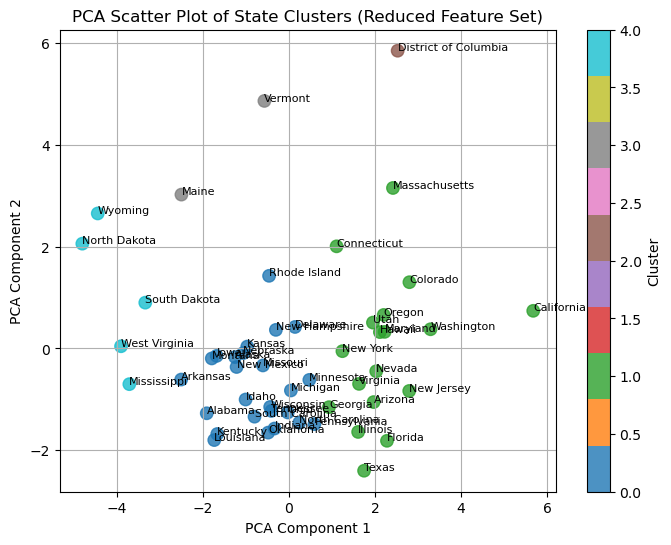

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load reduced clustering result
df_reduced = pd.read_csv("state_clusters_output_reduced.csv")

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    df_reduced["pca_1"],
    df_reduced["pca_2"],
    c=df_reduced["cluster_reduced"],
    cmap="tab10",
    s=80,
    alpha=0.8
)

for i, state in enumerate(df_reduced["State"]):
    plt.text(
        df_reduced["pca_1"].iloc[i],
        df_reduced["pca_2"].iloc[i],
        state,
        fontsize=8
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Scatter Plot of State Clusters (Reduced Feature Set)")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()

# 1.11 Interpretation of PCA Clustering Results

The PCA scatter plot provides a two-dimensional representation of the reduced feature space used in the clustering algorithm. Each point corresponds to a U.S. state, and the location of the point reflects the state's position along the first two principal components (PC1 and PC2). These principal components capture the main sources of variation in EV market characteristics across states.

The reduced-feature clustering results continue to show clear structural heterogeneity across U.S. EV markets. Although two weaker variables were removed from the original specification, the broad market typology remains stable and economically interpretable.

---

# Economic Interpretation of Principal Components

## Principal Component 1 (PC1)

The horizontal axis (PC1) primarily reflects **EV market maturity and adoption strength**. States located on the right side of the plot tend to have:

- higher EV registration intensity  
- higher urbanisation  
- stronger charging infrastructure density  
- higher income levels  

Examples include **California, Washington, Massachusetts, Colorado, and Connecticut**, which are all located on the right-hand side and belong to the mature EV market cluster.

By contrast, states on the left side of the plot generally have weaker EV adoption, lower infrastructure density, and more limited urban market conditions. These are typically lower-density or less mature EV markets.

Therefore, PC1 can be interpreted as a **market maturity gradient**, ranging from weaker and less developed EV markets on the left to stronger and more mature EV markets on the right.

---

## Principal Component 2 (PC2)

The vertical axis (PC2) appears to distinguish states with **more unusual infrastructure or urban structure** from those with more conventional market profiles.

States located high on the PC2 axis include:

- **District of Columbia**, which is an extreme urban outlier
- **Vermont** and **Maine**, which form part of an infrastructure-heavy niche cluster
- several mature states such as **Massachusetts** and **Connecticut**

These states differ from the rest either because of exceptionally high urban concentration or because they exhibit unusually strong charging infrastructure relative to their size.

Taken together, PC1 and PC2 provide a simplified but economically meaningful representation of differences in EV demand, infrastructure provision, urbanisation, and market scale.

---

# Cluster Separation

The PCA projection shows that the reduced K-Means model successfully separates the states into five distinct groups.

In particular:

- **Cluster 1 (green)** occupies the right side of the plot and represents **mature EV markets**, characterised by strong demand, high income, urbanisation, and developed infrastructure.
- **Cluster 2 (brown)** is a clear **urban outlier**, represented by the District of Columbia.
- **Cluster 3 (grey)** includes states such as **Maine** and **Vermont**, which form **infrastructure-heavy niche markets**.
- **Cluster 0 (blue)** is concentrated around the centre-left and represents **emerging EV markets** with moderate demand and developing infrastructure.
- **Cluster 4 (cyan)** is positioned furthest to the left and captures **low-adoption rural markets**, including states such as **North Dakota, Wyoming, and South Dakota**.

This separation indicates that the clustering process captures meaningful differences in EV market structure rather than arbitrary statistical variation.

---

# Why California and Other Mature Markets Appear on the Right Side

States such as **California, Washington, Massachusetts, Colorado, and Connecticut** appear on the right side of the PCA plot because they combine several characteristics associated with mature EV markets:

- relatively strong EV adoption intensity  
- higher household income  
- high urbanisation  
- denser charging infrastructure networks  

California, in particular, appears as one of the clearest mature-market observations because of its large EV market scale and strong infrastructure provision. Other states in the same cluster share similar characteristics, even if they are smaller in absolute size.

These states therefore occupy the high end of the EV market maturity spectrum captured by PC1.

---

# Why Rural and Low-Adoption States Appear on the Left Side

Several states located on the left side of the PCA plot—such as **North Dakota, Wyoming, South Dakota, and West Virginia**—share structural characteristics associated with lower-adoption rural EV markets.

These states typically have:

- low population density  
- lower urbanisation  
- weaker EV adoption intensity  
- less developed charging infrastructure  

Because EV charging networks tend to expand more slowly in sparsely populated markets, these states remain at the lower end of the EV market maturity gradient and therefore appear toward the left side of the PCA space.

---

# Implications for EV Market Segmentation

The reduced-feature clustering results confirm that EV market development in the United States is not uniform. Instead, states fall into distinct market segments reflecting differences in urban structure, socio-economic conditions, infrastructure provision, and EV adoption intensity.

Broadly, the five reduced clusters can be interpreted as:

- **mature EV markets**  
- **emerging EV markets**  
- **urban outlier markets**  
- **infrastructure-heavy niche markets**  
- **low-adoption rural markets**

This reduced specification preserves the same broad market typology as the full model while improving cluster separation. In the next step, these clusters are interpreted more systematically through **demand, supply, pressure, and growth indicators**.

# 1.12 PCA Loadings Interpretation

While the PCA scatter plot shows how states are positioned in the reduced two-dimensional space, it is also important to understand **which variables drive the principal components**. This can be interpreted by considering the reduced feature specification and the cluster profiles.

In the reduced model, the retained variables describe four broad dimensions of EV markets:

- EV adoption intensity  
- infrastructure density  
- urban structure  
- market scale and socio-economic capacity  

The first two principal components summarise how these dimensions vary across states.

---

## Variables Driving PC1

In the reduced specification, PC1 is most naturally interpreted as a dimension of **EV market maturity and adoption strength**.

The variables most relevant to this dimension are those describing:

- EV adoption intensity (`registrations_per_1k_pop`)  
- charging infrastructure availability (`stations_per_100k`, `ports_per_100k`)  
- urbanisation (`URBAN POP_PCT`)  
- market scale (`log1p_Population`, `log1p_Registration Count`)  

Together, these variables help explain why mature EV markets are located on the right side of the PCA space, while lower-adoption and less developed markets appear on the left.

In particular, **California, Washington, Massachusetts, and Colorado** are positioned toward the right because they combine relatively strong EV demand with more developed charging infrastructure and highly urbanised market conditions.

---

## Variables Driving PC2

PC2 is better interpreted as a dimension of **market structure and infrastructure configuration**.

The vertical separation appears to reflect whether a state has an unusual combination of:

- infrastructure density relative to market size  
- urban concentration  
- market scale  

This helps explain why:

- **District of Columbia** appears very high on the vertical axis as an extreme urban outlier
- **Maine** and **Vermont** also appear relatively high, reflecting unusually strong charging provision relative to their scale
- many emerging and rural states remain lower on the axis because they have more conventional, lower-intensity market structures

Thus, while PC1 captures broad EV market maturity, PC2 captures more specialised structural differences across states.

---

## Interpretation

Taken together, the reduced-feature PCA suggests that the dominant source of variation across U.S. EV markets is the contrast between **mature, urbanised, infrastructure-rich markets** and **lower-adoption, lower-density markets**.

The second component adds a further distinction between ordinary markets and more unusual cases, such as highly urbanised outliers or infrastructure-heavy niche markets.

This interpretation is consistent with the reduced clustering results:

- **Cluster 1** contains mature EV markets  
- **Cluster 2** captures the urban outlier  
- **Cluster 3** captures infrastructure-heavy niche states  
- **Cluster 0** contains emerging markets  
- **Cluster 4** represents low-adoption rural markets  

Overall, the PCA results provide a strong visual and economic interpretation of the reduced clustering specification and help explain why the final segmentation remains meaningful after removing two weakly informative variables.


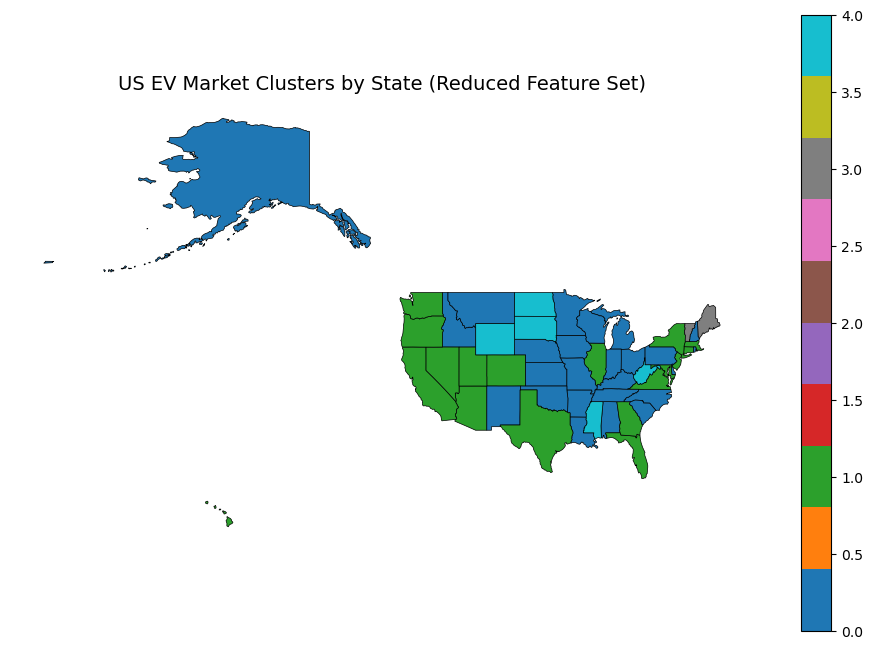

In [8]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Load reduced clustering result
df_reduced = pd.read_csv("state_clusters_output_reduced.csv")

# Load US states map
states = gpd.read_file(
    "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
)

# Merge map with reduced clustering output
map_df = states.merge(
    df_reduced,
    left_on="name",
    right_on="State",
    how="left"
)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

map_df.plot(
    column="cluster_reduced",
    cmap="tab10",
    edgecolor="black",
    linewidth=0.5,
    legend=True,
    ax=ax
)

ax.set_title("US EV Market Clusters by State (Reduced Feature Set)", fontsize=14)
ax.axis("off")

plt.show()

In [9]:
import pandas as pd

cluster_profile_reduced = pd.read_csv("cluster_profile_kmeans_reduced.csv", index_col=0)

print(cluster_profile_reduced.round(3))

                 Mean households income  Population Density  URBAN POP_PCT  \
cluster_reduced                                                              
0                             76448.800             164.495         68.692   
1                             89618.889             331.738         86.644   
2                            111000.000           11130.690        100.000   
3                             80465.000              43.420         36.850   
4                             70274.000              62.574         54.220   

                 stations_per_100k  ports_per_100k  stations_per_1k_reg  \
cluster_reduced                                                           
0                           15.308          42.340               35.722   
1                           28.537          85.673               23.804   
2                           46.589         159.840               39.425   
3                           57.770         147.621               77.095   
4  

In [10]:
import pandas as pd

cluster_summary_reduced = pd.DataFrame({
    "Cluster": ["C0", "C1", "C2", "C3", "C4"],
    "Market Type": [
        "Emerging markets",
        "Mature EV markets",
        "Urban outlier",
        "Infrastructure-heavy niche",
        "Low-adoption rural markets"
    ],
    "Key Characteristics": [
        "Moderate demand and developing infrastructure",
        "High income and strong EV adoption",
        "Extreme density and full urbanisation",
        "High charger density but smaller scale",
        "Low density and weak EV penetration"
    ]
})

print(cluster_summary_reduced)

  Cluster                 Market Type  \
0      C0            Emerging markets   
1      C1           Mature EV markets   
2      C2               Urban outlier   
3      C3  Infrastructure-heavy niche   
4      C4  Low-adoption rural markets   

                             Key Characteristics  
0  Moderate demand and developing infrastructure  
1             High income and strong EV adoption  
2          Extreme density and full urbanisation  
3         High charger density but smaller scale  
4            Low density and weak EV penetration  


# Step 2. Economic Interpretation of Clusters

After completing the reduced-feature clustering analysis in Step 1, the next stage is to interpret the economic meaning of each cluster rather than treating the results as a purely technical classification exercise. The aim of Step 2 is to translate the cluster labels into meaningful market structures from the perspectives of **demand**, **supply**, **infrastructure pressure**, and **growth potential**. This allows the clustering output to support strategic conclusions, instead of stopping at a descriptive segmentation of states.

The reduced clustering specification is used as the main model in the following analysis because it improves cluster separation while preserving the same broad EV market typology identified in the full model.

---

# 2.1 Objective

- which clusters correspond to stronger EV demand,
- which clusters are better supplied with charging infrastructure,
- which clusters face tighter infrastructure pressure,
- and which clusters may offer stronger future growth potential.

This step therefore converts the clustering results into a more interpretable market typology.

---

# 2.2 Input Data

Step 2 combines the original state-level dataset with the clustering output from Step 1.

The original data provide the economic and infrastructure variables, including:

- `Registration Count`
- `Mean households income`
- `Population`
- `Population Density`
- `URBAN POP`
- `URBAN POP_PCT`
- `EV Charging Station`
- `EV Charging Port`

The reduced clustering output provides:

- `cluster_reduced`
- `pca_1`
- `pca_2`

These two datasets are merged by `State`, so that each state has both its original characteristics and its assigned market cluster.

---

# 2.3 Feature Construction

To make cluster interpretation more meaningful, several additional indicators are constructed. These derived variables focus on ratios and intensities, which are more informative than raw totals when comparing states of very different sizes.

## Demand indicators

Demand-side measures aim to capture the strength and concentration of EV adoption.

**Registrations per 1,000 population**

$$
registrations\_per\_1k\_pop =
\frac{Registration\ Count}{Population} \times 1000
$$

**Mean households income**

This serves as a proxy for purchasing power and the affordability of EV adoption.

**Urban population percentage**

This reflects the degree of urbanisation, which is often associated with stronger EV demand and greater suitability for charging networks.

---

## Supply indicators

Supply-side measures capture the availability and density of charging infrastructure.

**Stations per 100,000 population**

$$
stations\_per\_100k\_pop =
\frac{EV\ Charging\ Station}{Population} \times 100000
$$

**Ports per 100,000 population**

$$
ports\_per\_100k\_pop =
\frac{EV\ Charging\ Port}{Population} \times 100000
$$

**Stations per 1,000 registrations**

$$
stations\_per\_1k\_reg =
\frac{EV\ Charging\ Station}{Registration\ Count} \times 1000
$$

**Ports per 1,000 registrations**

$$
ports\_per\_1k\_reg =
\frac{EV\ Charging\ Port}{Registration\ Count} \times 1000
$$

These indicators compare infrastructure provision both relative to population size and relative to existing EV demand.

---

## Competition / Infrastructure Pressure Indicators

Because brand-level competitor data are not available, direct competition cannot be measured precisely. Instead, infrastructure pressure is used as a proxy for market tightness.

**Registrations per charging port**

$$
registrations\_per\_port =
\frac{Registration\ Count}{EV\ Charging\ Port}
$$

**Registrations per charging station**

$$
registrations\_per\_station =
\frac{Registration\ Count}{EV\ Charging\ Station}
$$

Higher values indicate that more EVs rely on each charging point, suggesting tighter infrastructure conditions.

---

## Growth Potential Indicator

To approximate future expansion opportunity, a simple demand–supply gap measure is constructed:

$$
demand\_supply\_gap =
\frac{registrations\_per\_1k\_pop}{ports\_per\_100k\_pop}
$$

A larger value suggests that demand intensity is high relative to infrastructure provision, which may indicate stronger room for market expansion.

---

# 2.4 Cluster-Level Economic Profiles

After constructing these variables, the next step is to summarise them by cluster by calculating the mean values of indicators within each reduced cluster.

Four cluster-level profile tables are produced.

## Demand profile

Variables included:

- `Registration Count`
- `registrations_per_1k_pop`
- `Mean households income`
- `URBAN POP_PCT`
- `Population Density`

The purpose is to identify which clusters represent stronger EV demand, higher purchasing power, and more urbanised market environments.

---

## Supply profile

Variables included:

- `EV Charging Station`
- `EV Charging Port`
- `stations_per_100k_pop`
- `ports_per_100k_pop`
- `stations_per_1k_reg`
- `ports_per_1k_reg`

This profile compares the quantity and density of charging infrastructure across clusters.

---

## Competition / Infrastructure Pressure Profile

Variables included:

- `registrations_per_station`
- `registrations_per_port`

The objective is to identify clusters where EV demand places more pressure on charging infrastructure.

---

## Growth profile

Variables included:

- `registrations_per_1k_pop`
- `ports_per_100k_pop`
- `demand_supply_gap`

This profile evaluates whether clusters combine strong demand with relatively constrained infrastructure, indicating potential for future growth.

---

# 2.5 Reduced Cluster Typology

Based on the reduced clustering results, the five clusters can be interpreted as follows.

## Cluster 0: Emerging EV Markets

Cluster 0 contains states with moderate income, moderate urbanisation, and developing EV adoption. These states do not yet exhibit the strongest EV demand or the densest infrastructure networks, but they represent markets where EV diffusion is underway.

This cluster can therefore be interpreted as an **emerging EV market segment**.

---

## Cluster 1: Mature EV Markets

Cluster 1 includes states with relatively high income, strong urbanisation, and high EV adoption intensity. These markets also have more developed charging infrastructure and correspond to the most advanced EV markets in the dataset.

This cluster represents **mature EV markets** and includes many of the states that lead EV adoption in the United States.

---

## Cluster 2: Urban Outlier Market

Cluster 2 is characterised by extremely high population density, full urbanisation, and a distinct market structure that separates it clearly from the rest of the country.

This cluster is best interpreted as an **urban outlier market**, represented by the District of Columbia.

---

## Cluster 3: Infrastructure-Heavy Niche Markets

Cluster 3 contains states with relatively small market scale but unusually high charging density relative to population and EV registrations.

These states are best interpreted as **infrastructure-heavy niche markets**, where infrastructure provision is strong despite smaller market size.

---

## Cluster 4: Low-Adoption Rural Markets

Cluster 4 contains states with relatively weak EV adoption, lower density, and more limited infrastructure provision.

This cluster therefore represents **low-adoption rural markets**, where EV market development remains at an early stage.

---

# 2.6 Cluster Summary Scores

To simplify cluster comparison, Step 2 constructs several dimension scores.

## Demand score

Based on percentile ranks of:

- `registrations_per_1k_pop`
- `Mean households income`
- `URBAN POP_PCT`

A higher score indicates stronger EV demand fundamentals.

---

## Supply score

Based on percentile ranks of:

- `stations_per_100k_pop`
- `ports_per_100k_pop`

A higher score indicates stronger infrastructure provision.

---

## Infrastructure pressure score

Based on percentile ranks of:

- `registrations_per_station`
- `registrations_per_port`

Higher scores indicate tighter infrastructure conditions.

---

## Growth potential score

Growth potential combines demand strength and infrastructure pressure. Clusters with relatively strong demand but constrained infrastructure are interpreted as having greater expansion opportunities.

---

# 2.7 Cluster Selection for Strategic Targeting

After computing these summary scores, the next step is to identify the **high-potential cluster**.

The target cluster should typically exhibit:

- relatively strong demand fundamentals,
- sufficient infrastructure to support adoption,
- and signs of continued unmet or growing market need.

In practice, the most attractive cluster is not necessarily the most extreme outlier, nor the weakest rural market, but a cluster that combines strong demand with continued room for expansion.

Within the reduced clustering structure, **Cluster 1** is the most plausible high-potential segment because it represents mature EV markets with strong demand, high urbanisation, and relatively advanced infrastructure.

By contrast:

- **Cluster 2** is too idiosyncratic to serve as a broad target market,
- **Cluster 3** is a niche segment,
- **Cluster 4** remains too weak in overall adoption,
- and **Cluster 0** is more moderate and emerging than immediately high-priority.

---

# 2.8 Ranking States within the Target Cluster

Once the most promising cluster has been identified, states within that cluster are ranked using a composite priority score.

The ranking uses the following variables:

- `registrations_per_1k_pop`
- `Mean households income`
- `URBAN POP_PCT`
- `ports_per_100k_pop`
- `registrations_per_port`

Each variable is scaled to the range \([0,1]\) within the selected cluster, and a weighted average is used to calculate a **state priority score**.

This step enables the analysis to move from cluster-level market segmentation to **state-level market prioritisation**.

Within the reduced clustering framework, this means identifying which mature EV markets within **Cluster 1** are the most attractive for market entry or expansion.

---

# 2.9 Interpretation

The key purpose of Step 2 is to translate clustering results into economically meaningful insights. Rather than simply stating that states are divided into several clusters, the analysis explains how these clusters differ in terms of EV demand, infrastructure supply, and market opportunity.

The reduced clustering specification leads to a clear and interpretable market typology:

- **Cluster 1** captures mature EV markets,
- **Cluster 0** captures emerging EV markets,
- **Cluster 2** captures the urban outlier,
- **Cluster 3** captures infrastructure-heavy niche markets,
- **Cluster 4** captures low-adoption rural markets.

This reduced specification preserves the same broad market structure as the full model while producing stronger cluster separation. It therefore provides a more concise and robust basis for the strategic analysis that follows.

Overall, Step 2 transforms the reduced clustering results into a framework that supports market targeting and business decision-making.


In [11]:
import numpy as np
import pandas as pd


# ============================================
# 1. Load raw state data + reduced clustering output
# ============================================
df_raw = pd.read_csv("datas_by_states.csv")

df_cluster = pd.read_csv("state_clusters_output_reduced.csv")

df_out = df_raw.merge(
    df_cluster,
    on="State",
    how="left"
)

print(df_out.head())
print(df_out.columns)


def add_step2_market_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """Create interpretable market metrics for Step 2 analysis.

    This version is aligned with the reduced clustering specification.
    The goal is not to re-cluster, but to translate cluster labels into
    economic meaning: demand, supply, infrastructure pressure, and growth.
    """
    out = df.copy()

    # -----------------------------
    # Demand-side indicators
    # -----------------------------
    out["registrations_per_1k_pop"] = (
        out["Registration Count"] / out["Population"] * 1000
    )

    out["urban_pop_share"] = out["URBAN POP_PCT"] / 100.0

    # -----------------------------
    # Supply-side indicators
    # -----------------------------
    out["stations_per_100k_pop"] = (
        out["EV Charging Station"] / out["Population"] * 100000
    )

    out["ports_per_100k_pop"] = (
        out["EV Charging Port"] / out["Population"] * 100000
    )

    out["stations_per_1k_reg"] = (
        out["EV Charging Station"] / out["Registration Count"] * 1000
    )

    out["ports_per_1k_reg"] = (
        out["EV Charging Port"] / out["Registration Count"] * 1000
    )

    # -----------------------------
    # Competition / infrastructure pressure
    # -----------------------------
    out["registrations_per_port"] = (
        out["Registration Count"] / out["EV Charging Port"]
    )

    out["registrations_per_station"] = (
        out["Registration Count"] / out["EV Charging Station"]
    )

    # -----------------------------
    # Growth potential
    # -----------------------------
    out["demand_supply_gap"] = (
        out["registrations_per_1k_pop"] / out["ports_per_100k_pop"]
    )

    # Clean numerical issues
    out.replace([np.inf, -np.inf], np.nan, inplace=True)
    out.fillna(0.0, inplace=True)

    return out


def build_cluster_dimension_profiles(
    df: pd.DataFrame
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Summarise each reduced cluster from four perspectives."""

    # Demand profile
    demand_vars = [
        "Registration Count",
        "registrations_per_1k_pop",
        "Mean households income",
        "URBAN POP_PCT",
        "Population Density",
    ]

    # Supply profile
    supply_vars = [
        "EV Charging Station",
        "EV Charging Port",
        "stations_per_100k_pop",
        "ports_per_100k_pop",
        "stations_per_1k_reg",
        "ports_per_1k_reg",
    ]

    # Competition / infrastructure pressure profile
    competition_vars = [
        "registrations_per_station",
        "registrations_per_port",
    ]

    # Growth profile
    growth_vars = [
        "registrations_per_1k_pop",
        "ports_per_100k_pop",
        "demand_supply_gap",
    ]

    demand_profile = (
        df.groupby("cluster_reduced")[demand_vars]
        .mean(numeric_only=True)
        .round(3)
    )

    supply_profile = (
        df.groupby("cluster_reduced")[supply_vars]
        .mean(numeric_only=True)
        .round(3)
    )

    competition_profile = (
        df.groupby("cluster_reduced")[competition_vars]
        .mean(numeric_only=True)
        .round(3)
    )

    growth_profile = (
        df.groupby("cluster_reduced")[growth_vars]
        .mean(numeric_only=True)
        .round(3)
    )

    return demand_profile, supply_profile, competition_profile, growth_profile


def build_cluster_summary_scores(df: pd.DataFrame) -> pd.DataFrame:
    """Build compact cluster-level scores for reduced clusters."""

    cluster_means = df.groupby("cluster_reduced").mean(numeric_only=True).copy()

    # -----------------------------
    # Demand score
    # -----------------------------
    demand_score = (
        cluster_means["registrations_per_1k_pop"].rank(pct=True)
        + cluster_means["Mean households income"].rank(pct=True)
        + cluster_means["URBAN POP_PCT"].rank(pct=True)
    ) / 3

    # -----------------------------
    # Supply score
    # -----------------------------
    supply_score = (
        cluster_means["stations_per_100k_pop"].rank(pct=True)
        + cluster_means["ports_per_100k_pop"].rank(pct=True)
    ) / 2

    # -----------------------------
    # Infrastructure pressure score
    # -----------------------------
    pressure_score = (
        cluster_means["registrations_per_station"].rank(pct=True)
        + cluster_means["registrations_per_port"].rank(pct=True)
    ) / 2

    # -----------------------------
    # Growth potential score
    # -----------------------------
    growth_score = (
        demand_score.rank(pct=True)
        + pressure_score.rank(pct=True)
    ) / 2

    summary = pd.DataFrame({
        "demand_score": demand_score.round(3),
        "supply_score": supply_score.round(3),
        "pressure_score": pressure_score.round(3),
        "growth_potential_score": growth_score.round(3),
    })

    return summary.sort_index()


def rank_states_within_target_cluster(df: pd.DataFrame, target_cluster: int) -> pd.DataFrame:
    """Rank states inside a chosen reduced cluster for market prioritisation."""

    subset = df[df["cluster_reduced"] == target_cluster].copy()

    rank_cols = [
        "registrations_per_1k_pop",
        "Mean households income",
        "URBAN POP_PCT",
        "ports_per_100k_pop",
        "registrations_per_port",
    ]

    for col in rank_cols:
        min_val = subset[col].min()
        max_val = subset[col].max()

        if max_val == min_val:
            subset[f"{col}_scaled"] = 0.0
        else:
            subset[f"{col}_scaled"] = (subset[col] - min_val) / (max_val - min_val)

    subset["state_priority_score"] = (
        0.30 * subset["registrations_per_1k_pop_scaled"]
        + 0.20 * subset["Mean households income_scaled"]
        + 0.15 * subset["URBAN POP_PCT_scaled"]
        + 0.15 * subset["ports_per_100k_pop_scaled"]
        + 0.20 * subset["registrations_per_port_scaled"]
    )

    ranked = subset[
        [
            "State",
            "cluster_reduced",
            "Registration Count",
            "Mean households income",
            "URBAN POP_PCT",
            "ports_per_100k_pop",
            "registrations_per_port",
            "state_priority_score",
        ]
    ].sort_values("state_priority_score", ascending=False)

    return ranked.round(3)


# ============================================
# 2. Run Step 2 analysis
# ============================================

# Add Step 2 metrics
df_out = add_step2_market_metrics(df_out)

# Build four dimension tables
demand_profile, supply_profile, competition_profile, growth_profile = build_cluster_dimension_profiles(df_out)

print("Demand profile by reduced cluster:")
print(demand_profile)
print("\n")

print("Supply profile by reduced cluster:")
print(supply_profile)
print("\n")

print("Competition / infrastructure pressure profile by reduced cluster:")
print(competition_profile)
print("\n")

print("Growth profile by reduced cluster:")
print(growth_profile)
print("\n")

# Build compact summary score table
cluster_summary_scores = build_cluster_summary_scores(df_out)

print("Reduced cluster summary scores:")
print(cluster_summary_scores)
print("\n")

# Reduced model: Cluster 1 = Mature EV markets
target_cluster = 1
ranked_states = rank_states_within_target_cluster(df_out, target_cluster)

print(f"Ranked states within reduced cluster {target_cluster}:")
print(ranked_states)

# ============================================
# 3. Save outputs
# ============================================
demand_profile.to_csv("demand_profile_by_cluster_reduced.csv")
supply_profile.to_csv("supply_profile_by_cluster_reduced.csv")
competition_profile.to_csv("competition_profile_by_cluster_reduced.csv")
growth_profile.to_csv("growth_profile_by_cluster_reduced.csv")
cluster_summary_scores.to_csv("cluster_summary_scores_reduced.csv")
ranked_states.to_csv(f"ranked_states_cluster_reduced_{target_cluster}.csv", index=False)


        State  Registration Count  Mean households income  Population  \
0     Alabama               13047                   60660     5117850   
1      Alaska                2697                   98190      734654   
2     Arizona               89798                   82660     7452073   
3    Arkansas                7108                   63250     3069856   
4  California             1256646                   89870    39181667   

   Population Density  Mean travel time to work  URBAN POP  URBAN POP_PCT  \
0              100.87                      26.0    2900880           57.7   
1                1.29                      19.8     475967           64.9   
2               65.42                      26.4    6385230           89.3   
3               58.96                      22.7    1670677           55.5   
4              250.15                      29.7   37259490           94.2   

   EV Charging Station  EV Charging Port  cluster_reduced  \
0                  539              1

# 2.8 Strategic Implications for EV Market Entry

The reduced clustering and market structure analysis provide useful insights for EV manufacturers seeking to expand into the U.S. market. By combining the demand, infrastructure, pressure, and growth indicators, several strategic implications emerge for market entry and expansion.

---

# Target Market Segment

The analysis shows that **Cluster 1 represents the most attractive broad EV market segment** for strategic expansion.

This cluster combines several favourable characteristics:

- strong EV adoption intensity  
- relatively high household income  
- high urbanisation levels  
- developed charging infrastructure  
- high infrastructure utilisation, indicating continued and active market demand  

These characteristics suggest that Cluster 1 states represent **mature EV markets**, where consumer readiness for EV adoption is already well established and where EV demand is strong enough to support meaningful commercial expansion.

Although **Cluster 2** records high demand and supply scores, it is primarily an **urban outlier market** represented by the District of Columbia. It is therefore less suitable as a broad national market-entry template. Similarly, **Cluster 3** reflects a smaller infrastructure-heavy niche, while **Cluster 4** represents low-adoption rural markets with weaker short-term potential. **Cluster 0** is better interpreted as an emerging segment rather than the primary near-term target.

For EV manufacturers entering the U.S. market, **Cluster 1 provides the clearest combination of scale, demand strength, and strategic relevance**.

---

# Priority Entry States

Within Cluster 1, several states stand out as particularly attractive markets.

According to the state priority ranking, the highest-priority states include:

- **California**
- **Hawaii**
- **New Jersey**
- **Washington**
- **Massachusetts**
- **Colorado**

A second group of attractive markets includes:

- **Utah**
- **Nevada**
- **Maryland**
- **Oregon**
- **Arizona**

These states share several important characteristics:

- high or relatively strong EV adoption levels
- favourable household income conditions
- high urbanisation rates
- developed charging infrastructure
- strong infrastructure utilisation, suggesting continued market need

California is especially important, as it remains the **largest EV market in the United States** and is also the top-ranked state within the mature-market cluster. For a new EV entrant, establishing a strong presence in California can provide both market scale and brand visibility.

At the same time, some states in Cluster 1, such as **Massachusetts, Washington, New Jersey, and Maryland**, may offer particularly attractive combinations of income, urban density, and policy support. These markets can be seen as high-quality expansion targets even when their absolute size is smaller than California.

---

# Secondary Expansion Markets

After establishing a presence in the leading mature EV markets, firms may consider expanding into **Cluster 0**, which represents **emerging EV markets**.

These states typically have:

- moderate EV adoption
- developing charging infrastructure
- moderate urbanisation and income levels

Although demand is currently lower than in Cluster 1, these markets may experience **future growth** as infrastructure expands and EV adoption diffuses more widely. Entering these markets early may allow firms to establish market presence before competition intensifies further.

By contrast, **Cluster 4** should be viewed as a longer-term opportunity rather than an immediate expansion target, since it combines weak demand with low-density settlement patterns and limited infrastructure.

---

# Infrastructure Strategy

The infrastructure pressure indicators show that **Cluster 1** combines relatively strong demand with non-trivial infrastructure pressure. This suggests that many mature EV markets remain commercially attractive precisely because they are active and still expanding.

For EV manufacturers, this implies that successful market entry may require:

- partnerships with charging infrastructure providers  
- collaboration with state governments or local agencies  
- targeted investment in charging access or ecosystem support  

Expanding charging access alongside vehicle sales can help reduce infrastructure bottlenecks and support further market penetration.

---

# Product Positioning Strategy

The socio-economic characteristics of high-priority states suggest that EV demand is currently strongest in markets with:

- urban consumers  
- relatively high-income households  
- established environmental awareness  
- stronger infrastructure readiness  

Therefore, EV manufacturers entering the U.S. market may benefit from focusing on:

- mid-to-high-end EV models
- vehicles suited to urban and suburban commuting
- products compatible with well-developed public charging networks

The results also suggest that firms should avoid treating all U.S. states as identical markets. Instead, product deployment should be differentiated according to market maturity and local infrastructure conditions.

---

# Summary of Market Entry Strategy

Based on the reduced clustering analysis, a practical expansion strategy for EV manufacturers could follow three stages:

1. **Initial entry into mature EV markets (Cluster 1)**  
   Focus on states such as California, Washington, Massachusetts, and New Jersey.

2. **Expansion into emerging EV markets (Cluster 0)**  
   Target states where EV adoption is developing but long-term growth may be substantial.

3. **Long-term development in lower-density markets (Cluster 4)**  
   As infrastructure improves and EV adoption becomes more widespread, lower-adoption rural markets may gradually become more attractive.

This reduced clustering specification suggests that EV manufacturers should prioritise entry into **broad mature markets first**, while treating niche and rural clusters as either specialised or longer-term opportunities.

# 2.9 Geographic EV Market Strategy

The reduced clustering results also reveal clear geographic patterns in the development of EV markets across the United States. These spatial differences provide important insights for firms seeking to design an effective market entry strategy.

---

## West Coast: Leading Mature EV Markets

States on the U.S. West Coast, particularly **California, Washington, and Oregon**, are strongly represented in **Cluster 1**, the mature EV market segment.

These states combine several favourable conditions:

- strong EV adoption
- relatively advanced infrastructure
- high urbanisation
- supportive environmental and transport policy environments

California remains the most important case because of its market size, infrastructure scale, and national influence on EV regulation and industry expectations. Washington and Oregon also appear attractive as mature or near-mature coastal EV markets.

For EV manufacturers, the West Coast should be viewed as one of the most important initial entry regions.

---

## Northeast: High-Value Mature Markets

Several Northeastern states, including **Massachusetts, New Jersey, Connecticut, Maryland, and New York**, also fall within the mature EV market cluster.

These markets are characterised by:

- relatively high household incomes
- strong urbanisation
- established EV demand
- relatively developed infrastructure networks

Although some of these states are smaller than California in absolute size, they represent **high-value EV markets** with strong purchasing power and relatively favourable conditions for EV penetration.

From a strategic perspective, the Northeast should be treated as a high-priority region for premium or mainstream EV expansion.

---

## Sunbelt and Mountain States: Diverse Expansion Opportunities

The reduced results also highlight a set of attractive non-coastal states within **Cluster 1**, including:

- **Colorado**
- **Utah**
- **Arizona**
- **Nevada**
- **Texas**
- **Florida**
- **Georgia**
- **Virginia**

These states are important because they show that mature EV market characteristics are not limited to the traditional coastal strongholds. Some of them combine large population bases with improving infrastructure and rising EV demand.

For EV manufacturers, these states may offer significant expansion opportunities beyond the most obvious coastal markets, especially where large urban areas and growing infrastructure support EV uptake.

---

## Emerging Interior Markets

Many states in the central and interior parts of the country fall into **Cluster 0**, the emerging market segment. These states generally exhibit:

- moderate demand
- moderate urbanisation
- developing infrastructure
- lower EV maturity than the leading markets

These markets may not be the first priority for entry, but they represent the **next wave of EV growth** if infrastructure and consumer awareness continue to improve.

---

## Low-Density Rural Markets

Several lower-density states in the central and northern parts of the country remain in **Cluster 4**, the low-adoption rural market segment. These markets continue to face structural barriers such as:

- large geographic distances  
- lower population density  
- weaker infrastructure coverage  

These states are more likely to become relevant in the long term than in the immediate expansion phase.

---

## Urban Outlier and Niche Markets

The reduced clustering also identifies:

- **Cluster 2** as an **urban outlier market**, represented by the District of Columbia
- **Cluster 3** as an **infrastructure-heavy niche market**, including states such as Maine and Vermont

These markets are economically interesting and useful for interpretation, but they are not the most representative targets for broad national expansion. Instead, they may be better viewed as special cases requiring more tailored entry strategies.

# 2.10 Policy and Regulatory Environment

In addition to economic and infrastructure conditions, policy support plays a critical role in shaping EV adoption patterns across states.

---

## Policy-Relevant Mature Markets

Many of the states in **Cluster 1** overlap with regions known for relatively supportive EV policy environments. Examples include:

- California
- Washington
- Massachusetts
- New Jersey
- New York
- Maryland

These states often combine:

- stronger environmental policy orientation
- more established EV incentives
- greater charging infrastructure investment
- higher public awareness of clean transport

This helps explain why many of them appear among the highest-priority markets in the reduced clustering results.

---

## Zero-Emission Vehicle (ZEV) Policy Relevance

Several high-priority markets, particularly **California** and many Northeastern states, are closely associated with strong zero-emission vehicle policy frameworks. These policies have contributed to:

- faster EV adoption
- stronger market readiness
- more supportive regulatory conditions for EV manufacturers

For automakers entering the U.S. market, prioritising states with stronger ZEV-related policy environments may reduce market-entry uncertainty and support faster scale-up.

---

## Consumer Incentives

State-level consumer incentives remain an important factor in reducing the cost of EV adoption. These may include:

- purchase subsidies  
- tax credits  
- reduced registration fees  
- HOV-lane access or related usage incentives  

Markets with stronger consumer incentives are often more likely to support early or accelerated EV uptake, especially in already urbanised and infrastructure-ready states.

---

## Charging Infrastructure Support

Federal and state-level infrastructure programmes also play an important role in shaping market potential. These include:

- charging infrastructure subsidies  
- public-private partnerships  
- corridor charging investment  
- utility-supported charging deployment  

For EV manufacturers, these policies matter because they can reduce the ecosystem barriers to adoption. In mature EV markets, infrastructure policy can support continued growth. In emerging EV markets, it can accelerate the transition toward higher adoption.

---

# Strategic Implications

Taken together, the reduced clustering results and the policy environment suggest that EV manufacturers should prioritise market entry in states that combine:

- strong EV demand
- high income levels
- high urbanisation
- relatively developed charging infrastructure
- supportive policy environments

The results indicate that **Cluster 1 states should be the primary focus of initial market entry**, especially high-ranking states such as California, Washington, Massachusetts, New Jersey, and Colorado. **Cluster 0** represents the most important secondary expansion segment, while **Clusters 2 and 3** should be treated as special cases and **Cluster 4** as a longer-term opportunity set.


In [12]:
def build_state_level_results_table(
    df: pd.DataFrame,
    cluster_summary_scores: pd.DataFrame,
    ranked_states: pd.DataFrame,
    target_cluster: int = 1
) -> pd.DataFrame:
    """Build a clean state-level results table for downstream city-level
    expansion modelling.

    The table combines:
    1. reduced-cluster labels from Stage 1,
    2. cluster interpretation labels,
    3. Step 2 cluster summary scores,
    4. within-target-cluster priority ranking,
    5. state abbreviation and expansion priority band.

    This output is intended to be merged later with city-level dealer data.
    """

    out = df.copy()

    # --------------------------------------------------
    # 1. Human-readable market interpretation
    # --------------------------------------------------
    market_type_map = {
        0: "Emerging EV markets",
        1: "Mature EV markets",
        2: "Urban outlier market",
        3: "Infrastructure-heavy niche markets",
        4: "Low-adoption rural markets",
    }

    cluster_role_map = {
        0: "Secondary expansion",
        1: "Primary target",
        2: "Special case",
        3: "Niche case",
        4: "Long-term opportunity",
    }

    out["market_type"] = out["cluster_reduced"].map(market_type_map)
    out["cluster_role"] = out["cluster_reduced"].map(cluster_role_map)
    out["target_cluster_flag"] = (out["cluster_reduced"] == target_cluster).astype(int)

    # --------------------------------------------------
    # 2. Add state abbreviation for later merge convenience
    # --------------------------------------------------
    state_abbr_map = {
        "Alabama": "AL",
        "Alaska": "AK",
        "Arizona": "AZ",
        "Arkansas": "AR",
        "California": "CA",
        "Colorado": "CO",
        "Connecticut": "CT",
        "Delaware": "DE",
        "District of Columbia": "DC",
        "Florida": "FL",
        "Georgia": "GA",
        "Hawaii": "HI",
        "Idaho": "ID",
        "Illinois": "IL",
        "Indiana": "IN",
        "Iowa": "IA",
        "Kansas": "KS",
        "Kentucky": "KY",
        "Louisiana": "LA",
        "Maine": "ME",
        "Maryland": "MD",
        "Massachusetts": "MA",
        "Michigan": "MI",
        "Minnesota": "MN",
        "Mississippi": "MS",
        "Missouri": "MO",
        "Montana": "MT",
        "Nebraska": "NE",
        "Nevada": "NV",
        "New Hampshire": "NH",
        "New Jersey": "NJ",
        "New Mexico": "NM",
        "New York": "NY",
        "North Carolina": "NC",
        "North Dakota": "ND",
        "Ohio": "OH",
        "Oklahoma": "OK",
        "Oregon": "OR",
        "Pennsylvania": "PA",
        "Rhode Island": "RI",
        "South Carolina": "SC",
        "South Dakota": "SD",
        "Tennessee": "TN",
        "Texas": "TX",
        "Utah": "UT",
        "Vermont": "VT",
        "Virginia": "VA",
        "Washington": "WA",
        "West Virginia": "WV",
        "Wisconsin": "WI",
        "Wyoming": "WY",
    }
    out["state_abbr"] = out["State"].map(state_abbr_map)

    # --------------------------------------------------
    # 3. Merge cluster-level Step 2 scores
    # --------------------------------------------------
    score_table = cluster_summary_scores.reset_index().copy()

    out = out.merge(
        score_table,
        on="cluster_reduced",
        how="left"
    )

    # --------------------------------------------------
    # 4. Merge state-level priority score
    # --------------------------------------------------
    priority_cols = ["State", "state_priority_score"]

    out = out.merge(
        ranked_states[priority_cols],
        on="State",
        how="left"
    )

    out["state_priority_score"] = out["state_priority_score"].fillna(0.0)

    # --------------------------------------------------
    # 5. Expansion priority band
    # --------------------------------------------------
    out["expansion_priority_band"] = "Non-target"

    out.loc[
        (out["target_cluster_flag"] == 1) &
        (out["state_priority_score"] >= 0.50),
        "expansion_priority_band"
    ] = "High"

    out.loc[
        (out["target_cluster_flag"] == 1) &
        (out["state_priority_score"] >= 0.30) &
        (out["state_priority_score"] < 0.50),
        "expansion_priority_band"
    ] = "Medium"

    out.loc[
        (out["target_cluster_flag"] == 1) &
        (out["state_priority_score"] < 0.30),
        "expansion_priority_band"
    ] = "Low"

    # --------------------------------------------------
    # 6. Sort for readability
    # --------------------------------------------------
    out = out.sort_values(
        by=[
            "target_cluster_flag",
            "state_priority_score",
            "growth_potential_score",
            "State"
        ],
        ascending=[False, False, False, True]
    ).reset_index(drop=True)

    # --------------------------------------------------
    # 7. Keep only clean columns for output
    # --------------------------------------------------
    final_cols = [
        "State",
        "state_abbr",
        "cluster_reduced",
        "market_type",
        "cluster_role",
        "target_cluster_flag",
        "expansion_priority_band",
        "demand_score",
        "supply_score",
        "pressure_score",
        "growth_potential_score",
        "state_priority_score",
        "Registration Count",
        "Mean households income",
        "Population",
        "Population Density",
        "URBAN POP_PCT",
        "EV Charging Station",
        "EV Charging Port",
        "registrations_per_1k_pop",
        "stations_per_100k_pop",
        "ports_per_100k_pop",
        "stations_per_1k_reg",
        "ports_per_1k_reg",
        "registrations_per_station",
        "registrations_per_port",
        "demand_supply_gap",
        "pca_1",
        "pca_2",
    ]

    existing_final_cols = [col for col in final_cols if col in out.columns]

    return out[existing_final_cols].round(4)

In [14]:
state_level_results = build_state_level_results_table(
    df=df_out,
    cluster_summary_scores=cluster_summary_scores,
    ranked_states=ranked_states,
    target_cluster=target_cluster
)

print("\nState-level results table:")
print(state_level_results.head(20).to_string(index=False))

state_level_results.to_csv("state_level_results_reduced.csv", index=False)
state_level_results.to_excel("state_level_results_reduced.xlsx", index=False)

print("- state_level_results_reduced.csv")


State-level results table:
               State state_abbr  cluster_reduced          market_type        cluster_role  target_cluster_flag expansion_priority_band  demand_score  supply_score  pressure_score  growth_potential_score  state_priority_score  Registration Count  Mean households income  Population  Population Density  URBAN POP_PCT  EV Charging Station  EV Charging Port  registrations_per_1k_pop  stations_per_100k_pop  ports_per_100k_pop  stations_per_1k_reg  ports_per_1k_reg  registrations_per_station  registrations_per_port  demand_supply_gap   pca_1   pca_2
          California         CA                1    Mature EV markets      Primary target                    1                    High         0.867           0.6             1.0                    0.90                 0.831             1256646                   89870    39181667              250.15           94.2                18905             62500                   32.0723                48.2496            159.5134